<a href="https://colab.research.google.com/github/YasiruMethmal123/Model-Hub/blob/main/Fruad%20Detection/scripts/Fruad_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
plt.style.use("seaborn-v0_8")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = df = pd.read_csv("/content/drive/MyDrive/ML/FruadDetection/creditcard.csv")

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [ ]:
missing = df.isna().sum().sum()
missing

np.int64(0)

<Axes: xlabel='Class'>

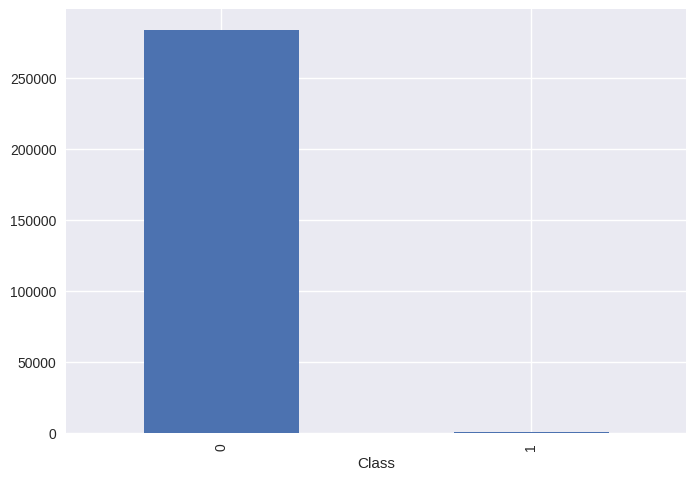

In [ ]:
#Plot a bar graph of class 0 and 1
df["Class"].value_counts().plot(kind="bar")


<Axes: xlabel='Class'>

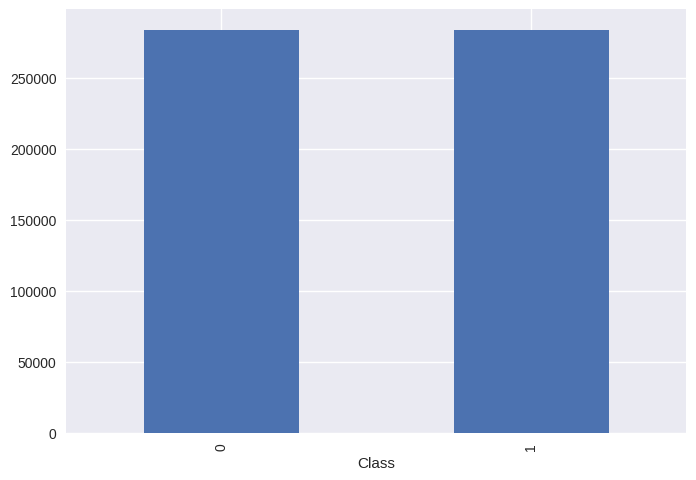

In [ ]:
#Apply Somte to treet the class imbalance
from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy="minority", random_state= 42)
X = df.drop("Class", axis=1)
y = df["Class"]

#Bar char after the samote
X_smote,y_smote = smote.fit_resample(X,y)
y_smote_value = y_smote.value_counts()
y_smote_value.plot(kind="bar")





## Preprocess part

In [ ]:
#chategorical values to numerical values
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_smote = scaler.fit_transform(X_smote)


In [ ]:
X_smote.shape

(568630, 30)

In [ ]:
y_smote.shape

(568630,)

In [ ]:
#Feature Selection for X and Y where y is the the dependant and X is the independant
from sklearn.model_selection import train_test_split
X_train ,X_test,y_train, y_test = train_test_split(X_smote , y_smote , random_state=42)

In [ ]:
# train the model using XGBoost
import xgboost as xgb
model = xgb.XGBClassifier(
    max_depth = 5,
    learning_rate = 0.1,
    n_estimators = 100,
    random_state = 42
)
model.fit(X_train,y_train)



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
#Model Evaluation with accuracy f1score percision recall
from sklearn.metrics import accuracy_score,f1_score,precision_score,recall_score
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test , y_pred)
f1 = f1_score(y_test , y_pred)
precision = precision_score(y_test , y_pred)
recall = recall_score(y_test,y_pred)

print(f"Accuracy : {accuracy *100} %")
print(f"F1 Score : {f1 *100} %")
print(f"Precision : {precision *100} %")
print(f"Recall : {recall*100} %")

Accuracy : 99.76997425399907 %
F1 Score : 99.77009878018772 %
Precision : 99.79465541490859 %
Recall : 99.74555422787658 %
